# SalesFlow Analytics — Prediction Completed

Готовая версия prediction: classification, confusion matrix, feature importance, regression, MAE/RMSE/R².

Clean Sales Dataset Loaded
Shape: (108552, 15)


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,ShipDateKey,SalesTerritoryKey,Order Quantity,Unit Price,Extended Amount,Unit Price Discount Pct,Product Standard Cost,Total Product Cost,Sales Amount
0,43659001,676,0,113,20170702,20170712,20170709.0,4,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
1,43659003,676,0,115,20170702,20170712,20170709.0,4,1,2024.994,2024.994,0,1898.0944,1898.0944,2024.994
2,43659004,676,0,108,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
3,43659005,676,0,109,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994
4,43659007,676,0,111,20170702,20170712,20170709.0,4,1,2039.994,2039.994,0,1912.1544,1912.1544,2039.994



Model Features
['CustomerKey', 'ProductKey', 'SalesTerritoryKey', 'Order Quantity', 'Unit Price', 'Unit Price Discount Pct', 'Year', 'Month']
Model data shape: (108552, 18)

Classification Result: High Value Purchase Prediction
Median Sales Amount threshold: $80.17
Accuracy: 0.9999

Classification Report:
              precision    recall  f1-score   support

   Low Value       1.00      1.00      1.00     10852
  High Value       1.00      1.00      1.00     10859

    accuracy                           1.00     21711
   macro avg       1.00      1.00      1.00     21711
weighted avg       1.00      1.00      1.00     21711



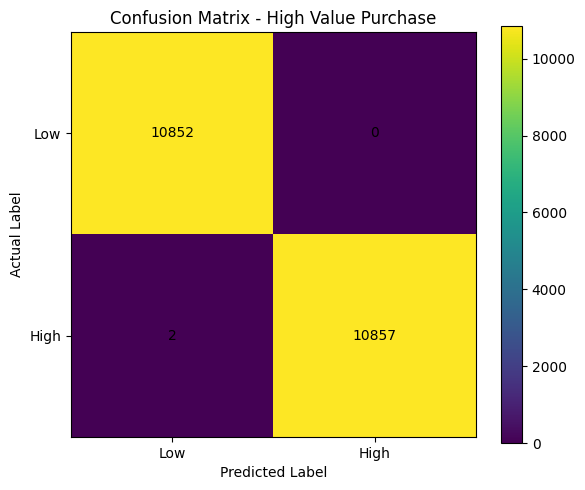

,Feature,Importance
4,Unit Price,0.573338
3,Order Quantity,0.152061
0,CustomerKey,0.122989
1,ProductKey,0.113001
6,Year,0.029465
2,SalesTerritoryKey,0.006401
7,Month,0.002744
5,Unit Price Discount Pct,0.000000


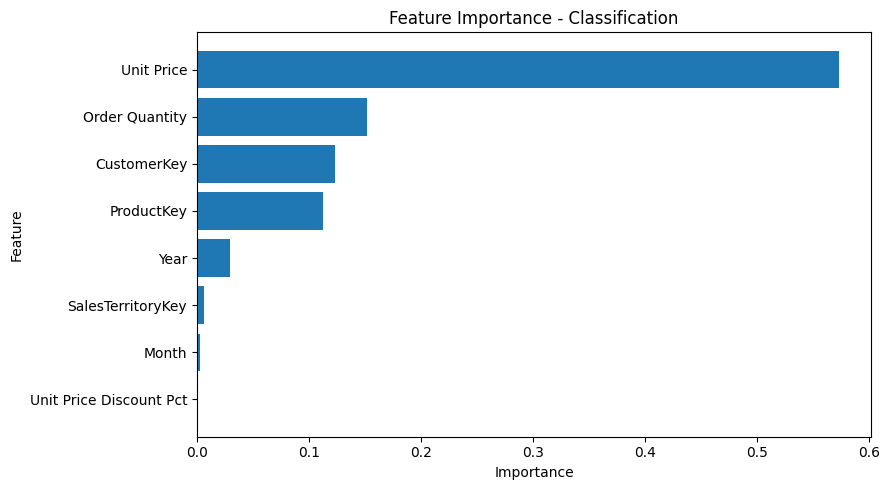


Regression Result: Sales Amount Prediction
MAE:  $0.14
RMSE: $3.18
R²:   1.0000


,Metric,Value
0,MAE,0.142937
1,RMSE,3.183113
2,R²,0.999982


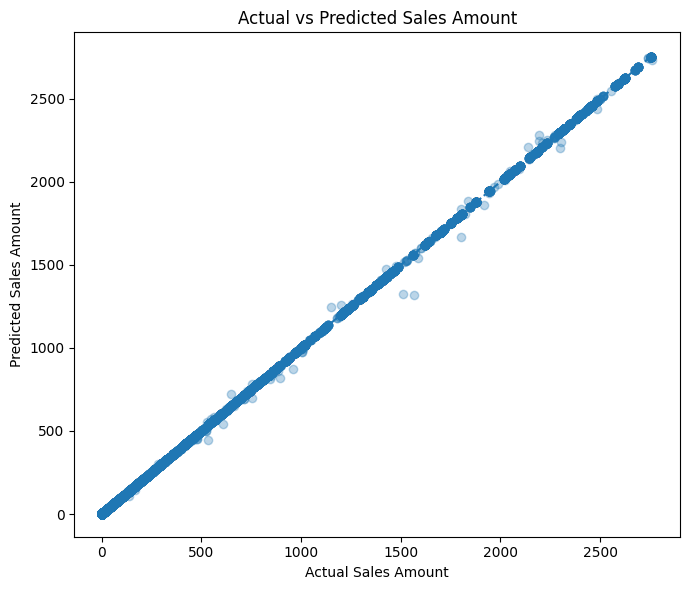

,Feature,Importance
4,Unit Price,0.867470
3,Order Quantity,0.130921
0,CustomerKey,0.001065
1,ProductKey,0.000518
6,Year,0.000018
2,SalesTerritoryKey,0.000004
7,Month,0.000004
5,Unit Price Discount Pct,0.000000


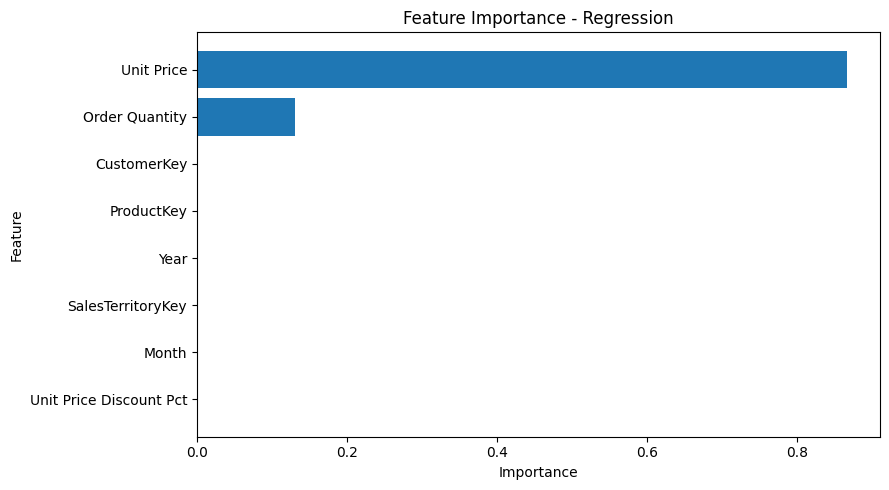


Final Prediction Insights

1. Classification was completed as High Value / Low Value purchase prediction.
   A true Buy / No Buy model requires non-purchase customer data, which is not included in the current dataset.

2. Classification accuracy: 0.9999

3. Regression was used to predict Sales Amount.

4. Regression metrics:
   - MAE:  $0.14
   - RMSE: $3.18
   - R²:   1.0000

5. Feature importance shows which variables have the strongest effect on customer purchase value.

6. Note: because Unit Price and Order Quantity are strongly related to Sales Amount, regression results may still be very strong.

6. These models can support:
   - CRM targeting
   - customer value prediction
   - product recommendation
   - sales forecasting
   - business decision support



In [1]:

# ============================================================
# SalesFlow Analytics
# 04 Prediction - Completed Version
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# Load clean dataset
# ------------------------------------------------------------
DATA_PATH = "clean_sales_data.csv"

if not os.path.exists(DATA_PATH):
    DATA_PATH = r"/mnt/data/clean_sales_data.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("Clean Sales Dataset Loaded")
print("=" * 60)
print("Shape:", df.shape)
display(df.head())

# ------------------------------------------------------------
# Create output folder for PPT charts
# ------------------------------------------------------------
CHART_DIR = "charts_prediction"
os.makedirs(CHART_DIR, exist_ok=True)

# ------------------------------------------------------------
# Feature preparation
# ------------------------------------------------------------
df_model = df.copy()

if "OrderDateKey" in df_model.columns:
    df_model["OrderDateKey"] = df_model["OrderDateKey"].astype(str)
    df_model["OrderDate"] = pd.to_datetime(df_model["OrderDateKey"], format="%Y%m%d", errors="coerce")
    df_model["Year"] = df_model["OrderDate"].dt.year
    df_model["Month"] = df_model["OrderDate"].dt.month

# We do NOT use "Sales Amount" as a feature because it is the target.
# We also avoid "Extended Amount" and "Total Product Cost" here because they are too directly connected
# with the target and can make the model look unrealistically perfect.
feature_cols = [
    "CustomerKey",
    "ProductKey",
    "SalesTerritoryKey",
    "Order Quantity",
    "Unit Price",
    "Unit Price Discount Pct",
    "Year",
    "Month"
]

feature_cols = [col for col in feature_cols if col in df_model.columns]

# Remove rows with missing model values
df_model = df_model.dropna(subset=feature_cols + ["Sales Amount"])

X = df_model[feature_cols]

print("\n" + "=" * 60)
print("Model Features")
print("=" * 60)
print(feature_cols)
print("Model data shape:", df_model.shape)

# ============================================================
# SECTION 1
# CLASSIFICATION
# ============================================================

# Important:
# Current dataset contains only completed sales transactions.
# It does not contain real "No Buy" rows.
# Therefore, a direct Buy / No Buy target would be invalid because all rows are purchases.
# For a meaningful classification model, we predict whether a transaction is High Value or Low Value.

median_sales = df_model["Sales Amount"].median()
df_model["HighValuePurchase"] = (df_model["Sales Amount"] >= median_sales).astype(int)

y_class = df_model["HighValuePurchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

clf = RandomForestClassifier(
    n_estimators=120,
    random_state=42,
    max_depth=12,
    n_jobs=-1
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("Classification Result: High Value Purchase Prediction")
print("=" * 60)
print(f"Median Sales Amount threshold: ${median_sales:,.2f}")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Value", "High Value"]))

# Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - High Value Purchase")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Low", "High"])
plt.yticks([0, 1], ["Low", "High"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_confusion_matrix.png"), dpi=200)
plt.show()

# Feature Importance - Classification
feature_importance_clf = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": clf.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_clf)

plt.figure(figsize=(9, 5))
plt.barh(feature_importance_clf["Feature"], feature_importance_clf["Importance"])
plt.title("Feature Importance - Classification")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_feature_importance_classification.png"), dpi=200)
plt.show()

# ============================================================
# SECTION 2
# REGRESSION
# ============================================================

y_reg = df_model["Sales Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg = RandomForestRegressor(
    n_estimators=120,
    random_state=42,
    max_depth=14,
    n_jobs=-1
)

reg.fit(X_train, y_train)

y_pred_reg = reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print("\n" + "=" * 60)
print("Regression Result: Sales Amount Prediction")
print("=" * 60)
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [mae, rmse, r2]
})
display(metrics_df)

# Actual vs Predicted Sales
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_reg, alpha=0.3)
plt.title("Actual vs Predicted Sales Amount")
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")

min_value = min(y_test.min(), y_pred_reg.min())
max_value = max(y_test.max(), y_pred_reg.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_actual_vs_predicted_sales.png"), dpi=200)
plt.show()

# Feature Importance - Regression
feature_importance_reg = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": reg.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_reg)

plt.figure(figsize=(9, 5))
plt.barh(feature_importance_reg["Feature"], feature_importance_reg["Importance"])
plt.title("Feature Importance - Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_feature_importance_regression.png"), dpi=200)
plt.show()

# ------------------------------------------------------------
# Final Prediction Insights
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("Final Prediction Insights")
print("=" * 60)

print(f"""
1. Classification was completed as High Value / Low Value purchase prediction.
   A true Buy / No Buy model requires non-purchase customer data, which is not included in the current dataset.

2. Classification accuracy: {accuracy:.4f}

3. Regression was used to predict Sales Amount.

4. Regression metrics:
   - MAE:  ${mae:,.2f}
   - RMSE: ${rmse:,.2f}
   - R²:   {r2:.4f}

5. Feature importance shows which variables have the strongest effect on customer purchase value.

6. Note: because Unit Price and Order Quantity are strongly related to Sales Amount, regression results may still be very strong.

6. These models can support:
   - CRM targeting
   - customer value prediction
   - product recommendation
   - sales forecasting
   - business decision support
""")
